# Capstone Project

##  PERSONALIZED VIRTUAL SHOPPING ASSISTANT ON WHATSAPP USING LLAMA STACK

### EDA_Retail Dataset

## Dataset

The columns provide information about the transactions, customers, products, and purchasing behavior, making the dataset suitable for various analyses, including market basket analysis and customer segmentation. Here's a brief explanation of each column in the Dataset:

  Transaction_ID: A unique identifier for each transaction, represented as a 10-digit number. This column is used to uniquely identify each purchase.

  Date: The date and time when the transaction occurred. It records the timestamp of each purchase.

  Customer_Name: The name of the customer who made the purchase. It provides information about the customer's identity.

  Product: A list of products purchased in the transaction. It includes the names of the products bought.

  Total_Items: The total number of items purchased in the transaction. It represents the quantity of products bought.

  Total_Cost: The total cost of the purchase, in currency. It represents the financial value of the transaction.

  Payment_Method: The method used for payment in the transaction, such as credit card, debit card, cash, or mobile payment.

  City: The city where the purchase took place. It indicates the location of the transaction.

  Store_Type: The type of store where the purchase was made, such as a supermarket, convenience store, department store, etc.

  Discount_Applied: A binary indicator (True/False) representing whether a discount was applied to the transaction.

  Customer_Category: A category representing the customer's background or age group.

  Season: The season in which the purchase occurred, such as spring, summer, fall, or winter.
  
  Promotion: The type of promotion applied to the transaction, such as "None," "BOGO (Buy One Get One)," or "Discount on Selected Items."



## EDA

#### Import required packages

In [ ]:
from matplotlib import pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import scipy
import os

In [ ]:
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

### Load the data


In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("prasad22/retail-transactions-dataset")

print("Path to dataset files:", path)

Path to dataset files: /root/.cache/kagglehub/datasets/prasad22/retail-transactions-dataset/versions/2


In [ ]:
df=pd.read_csv('/content/Retail_Transactions_Dataset.csv')

In [ ]:
df.head(2)

,Transaction_ID,Date,Customer_Name,Product,Total_Items,Total_Cost,Payment_Method,City,Store_Type,Discount_Applied,Customer_Category,Season,Promotion
0,1000000000,2022-01-21 06:27:29,Stacey Price,"['Ketchup', 'Shaving Cream', 'Light Bulbs']",3,71.65,Mobile Payment,Los Angeles,Warehouse Club,True,Homemaker,Winter,NaN
1,1000000001,2023-03-01 13:01:21,Michelle Carlson,"['Ice Cream', 'Milk', 'Olive Oil', 'Bread', 'P...",2,25.93,Cash,San Francisco,Specialty Store,True,Professional,Fall,BOGO (Buy One Get One)


In [ ]:
df.shape

(1000000, 13)

In [ ]:
df.dtypes

,0
Transaction_ID,int64
Date,object
Customer_Name,object
Product,object
Total_Items,int64
Total_Cost,float64
Payment_Method,object
City,object
Store_Type,object
Discount_Applied,bool


In [ ]:
df.isnull().sum()

,0
Transaction_ID,0
Date,0
Customer_Name,0
Product,0
Total_Items,0
Total_Cost,0
Payment_Method,0
City,0
Store_Type,0
Discount_Applied,0


In [ ]:
df.describe()

,Transaction_ID,Total_Items,Total_Cost
count,1.000000e+06,1000000.000000,1000000.000000
mean,1.000500e+09,5.495941,52.455220
std,2.886753e+05,2.871654,27.416989
min,1.000000e+09,1.000000,5.000000
25%,1.000250e+09,3.000000,28.710000
50%,1.000500e+09,5.000000,52.420000
75%,1.000750e+09,8.000000,76.190000
max,1.001000e+09,10.000000,100.000000


In [ ]:
# Flatten the List of Product
# Convert the 'Product' column (which should be a string representation of a list) into actual lists
df['Product'] = df['Product'].apply(lambda x: eval(x) if isinstance(x, str) else x)

In [ ]:
# Extract All Unique Items
# Flatten the list of items into one big list
all_items = [Product for sublist in df['Product'] for Product in sublist]

# Get unique items
unique_items = set(all_items)

# Convert to a sorted list (optional)
unique_items = sorted(list(unique_items))

# Display the unique items
print(unique_items)


['Air Freshener', 'Apple', 'BBQ Sauce', 'Baby Wipes', 'Banana', 'Bath Towels', 'Beef', 'Bread', 'Broom', 'Butter', 'Canned Soup', 'Carrots', 'Cereal', 'Cereal Bars', 'Cheese', 'Chicken', 'Chips', 'Cleaning Rags', 'Cleaning Spray', 'Coffee', 'Deodorant', 'Diapers', 'Dish Soap', 'Dishware', 'Dustpan', 'Eggs', 'Extension Cords', 'Feminine Hygiene Products', 'Garden Hose', 'Hair Gel', 'Hand Sanitizer', 'Honey', 'Ice Cream', 'Insect Repellent', 'Iron', 'Ironing Board', 'Jam', 'Ketchup', 'Laundry Detergent', 'Lawn Mower', 'Light Bulbs', 'Mayonnaise', 'Milk', 'Mop', 'Mustard', 'Olive Oil', 'Onions', 'Orange', 'Pancake Mix', 'Paper Towels', 'Pasta', 'Peanut Butter', 'Pickles', 'Plant Fertilizer', 'Potatoes', 'Power Strips', 'Razors', 'Rice', 'Salmon', 'Shampoo', 'Shaving Cream', 'Shower Gel', 'Shrimp', 'Soap', 'Soda', 'Spinach', 'Sponges', 'Syrup', 'Tea', 'Tissues', 'Toilet Paper', 'Tomatoes', 'Toothbrush', 'Toothpaste', 'Trash Bags', 'Trash Cans', 'Tuna', 'Vacuum Cleaner', 'Vinegar', 'Water',

In [ ]:
# Count the number of unique items
num_unique_items = len(unique_items)

# Print the count of unique items
print(f"Number of unique items: {num_unique_items}")

Number of unique items: 81


In [ ]:
# Check unique promotions
unique_promotions = df['Promotion'].unique()

# Display the unique promotions
print("Unique promotions:", unique_promotions)

Unique promotions: [nan 'BOGO (Buy One Get One)' 'Discount on Selected Items']


In [ ]:
# Check unique season
unique_season = df['Season'].unique()

# Display the unique season
print("Unique Season:", unique_season)

Unique Season: ['Winter' 'Fall' 'Spring' 'Summer']


In [ ]:
# The sum of 'Total_cost' for each category
category_total_cost = df.groupby('Customer_Category')['Total_Cost'].sum().reset_index()

# Check the aggregated data
category_total_cost.head()

,Customer_Category,Total_Cost
0,Homemaker,6579605.97
1,Middle-Aged,6532337.04
2,Professional,6547388.77
3,Retiree,6558223.95
4,Senior Citizen,6568220.19


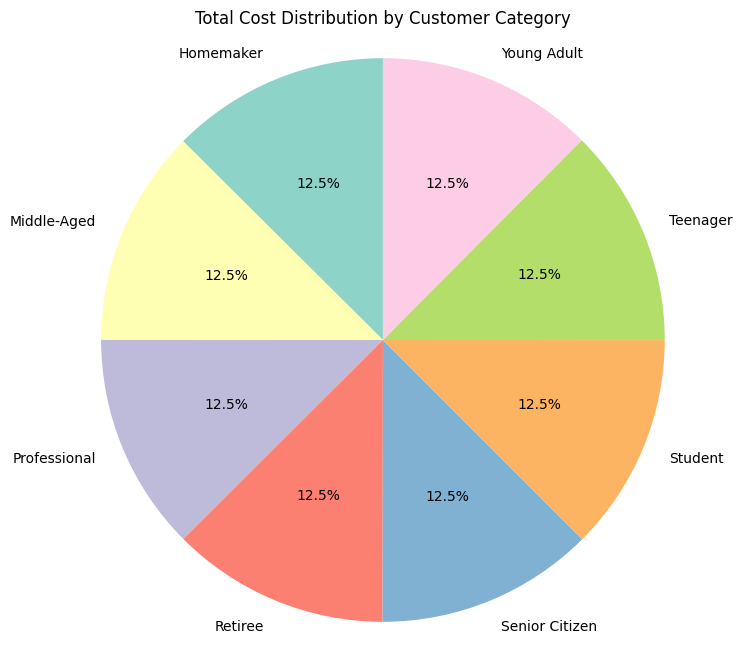

In [ ]:
plt.figure(figsize=(8, 8))

# Plotting the pie chart
plt.pie(category_total_cost['Total_Cost'],
        labels=category_total_cost['Customer_Category'],
        autopct='%1.1f%%',
        startangle=90,
        colors=sns.color_palette('Set3', len(category_total_cost)))

# Title for the chart
plt.title('Total Cost Distribution by Customer Category')

# Display the pie chart
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

In [ ]:
# The sum of 'Total_cost' for each category
category_total_cost = df.groupby('Customer_Category')['Total_Cost'].sum().reset_index()

# Check the aggregated data
category_total_cost.head()

,Customer_Category,Total_Cost
0,Homemaker,6579605.97
1,Middle-Aged,6532337.04
2,Professional,6547388.77
3,Retiree,6558223.95
4,Senior Citizen,6568220.19


In [ ]:
# The sum of 'Total_cost' for each city
city_total_cost = df.groupby('City')['Total_Cost'].sum().reset_index()

# Check the aggregated data
city_total_cost.head()

,City,Total_Cost
0,Atlanta,5202731.84
1,Boston,5263307.96
2,Chicago,5263187.45
3,Dallas,5277111.53
4,Houston,5247054.78


<ipython-input-21-e5929eb30542>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='City', y='Total_Cost', data=city_total_cost, palette='viridis')


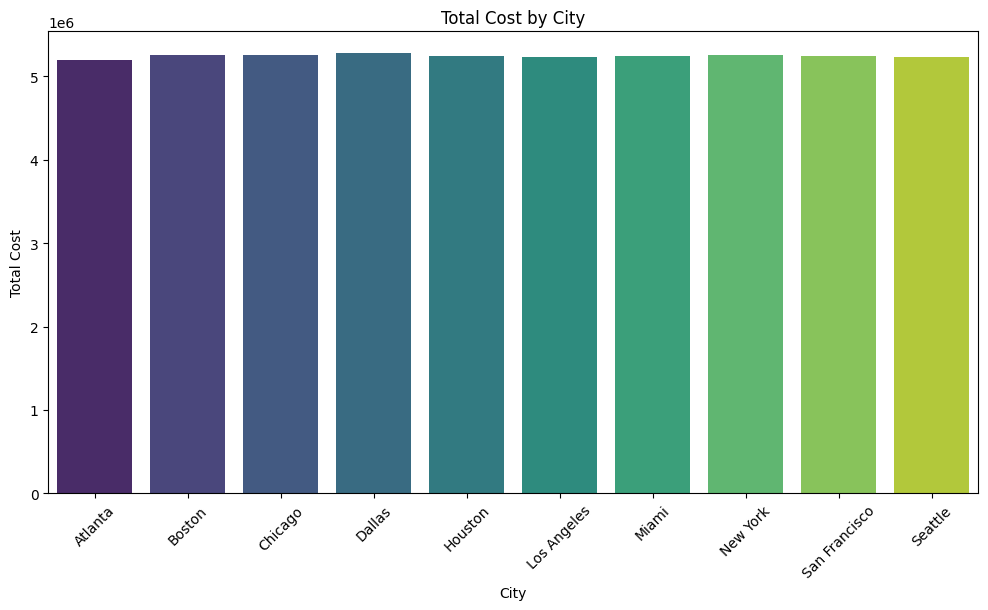

In [ ]:
# Create a bar chart for 'Total_Cost' by 'City'
plt.figure(figsize=(12, 6))

# plot the data
sns.barplot(x='City', y='Total_Cost', data=city_total_cost, palette='viridis')

# Set labels and title
plt.xlabel('City')
plt.ylabel('Total Cost')
plt.title('Total Cost by City')
plt.xticks(rotation=45)

plt.show()

In [ ]:
# The sum of 'Total_cost' for each Store_Type
store_Type_total_cost = df.groupby('Store_Type')['Total_Cost'].sum().reset_index()

# Check the aggregated data
store_Type_total_cost.head()

,Store_Type,Total_Cost
0,Convenience Store,8731901.36
1,Department Store,8731555.57
2,Pharmacy,8766679.01
3,Specialty Store,8701600.22
4,Supermarket,8763455.21


<ipython-input-23-156a9a6a5428>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Store_Type', y='Total_Cost', data=store_Type_total_cost, palette='Set2')


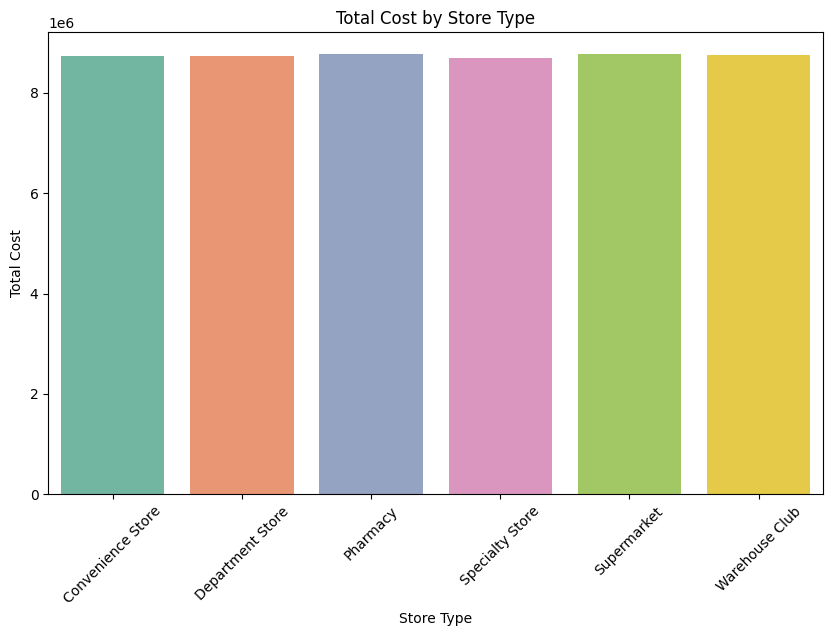

In [ ]:
# Create a bar chart for 'Total_Cost' by 'Store_Type'
plt.figure(figsize=(10, 6))

# plot the data
sns.barplot(x='Store_Type', y='Total_Cost', data=store_Type_total_cost, palette='Set2')

plt.xlabel('Store Type')
plt.ylabel('Total Cost')
plt.title('Total Cost by Store Type')

plt.xticks(rotation=45)

plt.show()

In [ ]:
# The sum of 'Total_cost' for each Payment Method
payment_method_total_cost = df.groupby('Payment_Method')['Total_Cost'].sum().reset_index()

# Check the aggregated data
payment_method_total_cost.head()

,Payment_Method,Total_Cost
0,Cash,13133235.30
1,Credit Card,13123764.94
2,Debit Card,13095216.24
3,Mobile Payment,13103003.92


## Data Preprocessing

In [ ]:
# We will first explode the product list so that each row represents a customer-product interaction.
df_exploded = df.explode('Product')
df_exploded.head()

,Transaction_ID,Date,Customer_Name,Product,Total_Items,Total_Cost,Payment_Method,City,Store_Type,Discount_Applied,Customer_Category,Season,Promotion
0,1000000000,2022-01-21 06:27:29,Stacey Price,Ketchup,3,71.65,Mobile Payment,Los Angeles,Warehouse Club,True,Homemaker,Winter,NaN
0,1000000000,2022-01-21 06:27:29,Stacey Price,Shaving Cream,3,71.65,Mobile Payment,Los Angeles,Warehouse Club,True,Homemaker,Winter,NaN
0,1000000000,2022-01-21 06:27:29,Stacey Price,Light Bulbs,3,71.65,Mobile Payment,Los Angeles,Warehouse Club,True,Homemaker,Winter,NaN
1,1000000001,2023-03-01 13:01:21,Michelle Carlson,Ice Cream,2,25.93,Cash,San Francisco,Specialty Store,True,Professional,Fall,BOGO (Buy One Get One)
1,1000000001,2023-03-01 13:01:21,Michelle Carlson,Milk,2,25.93,Cash,San Francisco,Specialty Store,True,Professional,Fall,BOGO (Buy One Get One)


In [ ]:
# # Create a user-item matrix
# interaction_matrix = df_exploded.pivot_table(index='Customer_Name', columns='Product', values='Total_Cost', aggfunc='sum').fillna(0)

# interaction_matrix.head()

In [ ]:
# Create a user-item matrix; used aagfunc=count as duplicate present in the total items column
interaction_matrix = df_exploded.pivot_table(index='Customer_Name', columns='Product', values='Total_Items', aggfunc='count').fillna(0)

interaction_matrix.head()

Product,Air Freshener,Apple,BBQ Sauce,Baby Wipes,Banana,Bath Towels,Beef,Bread,Broom,Butter,...,Tomatoes,Toothbrush,Toothpaste,Trash Bags,Trash Cans,Tuna,Vacuum Cleaner,Vinegar,Water,Yogurt
Customer_Name,,,,,,,,,,,,,,,,,,,,,
Aaron Acevedo,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
Aaron Acosta,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
Aaron Adams,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,...,1.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0
Aaron Adkins,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
Aaron Aguilar,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
